# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [49]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [6]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


# Diagnóstico de valores nulos

- users:
  - city tiene ~11.7% de nulos, por lo que conviene investigar e imputar si es posible.
  - churn_date tiene ~88.3% de nulos; probablemente significa clientes activos, así que se puede dejar como NA.

- usage:
  - date tiene ~0.1% de nulos, por lo que puede imputarse o eliminarse fácilmente.
  - duration tiene ~55.2% de nulos; probablemente depende del tipo de registro y debe investigarse antes de imputar.
  - length tiene ~44.7% de nulos; posiblemente asociado a mensajes/llamadas y requiere análisis antes de decidir.

### 2.2 Detección de valores inválidos y sentinels


- La columna `user_id` no presenta valores inválidos aparentes y los IDs parecen consistentes.

- La columna `age` debe revisarse porque podrían existir edades fuera de rango (negativas o demasiado altas), lo cual sería un sentinel o error de captura.

- Las columnas `id` y `user_id` de `usage` funcionan como identificadores y no muestran problemas evidentes.

- La columna `duration` tiene muchos valores nulos, probablemente porque no aplica para registros de mensajes.

- La columna `length` también presenta muchos nulos, posiblemente porque solo aplica para mensajes y no para llamadas.

- Es importante revisar si existen valores negativos o extremadamente altos en `duration` y `length`, ya que podrían representar errores de captura o sentinels.

In [15]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000



- La columna `user_id` parece consistente, ya que los IDs están dentro de un rango lógico y no presenta valores negativos o atípicos.

- La columna `age` presenta un valor mínimo de `-999`, lo cual es inválido para una edad y probablemente corresponde a un sentinel o error de captura.

In [16]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000



- Las columnas `id` y `user_id` parecen consistentes, ya que los identificadores están dentro de rangos lógicos y no presentan valores negativos.

- La columna `duration` presenta valores mínimos de 0 y máximos de 120, por lo que conviene revisar si las duraciones en 0 representan llamadas inválidas o registros incompletos.

- La columna `length` presenta valores extremos altos (máximo de 1490), lo que podría indicar mensajes muy largos o posibles outliers que deben investigarse.

In [17]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()

city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` presenta valores nulos y también un valor inválido representado por `"?"`, lo que sugiere datos faltantes o errores de captura que deben limpiarse.

- La columna `plan` parece consistente, ya que solamente contiene las categorías esperadas: `Basico` y `Premium`.

In [18]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` parece consistente, ya que únicamente contiene las categorías esperadas: `text` y `call`, sin valores nulos ni categorías inválidas.


 - En la columna `age` se encontró el valor `-999`, el cual es inválido para una edad y probablemente representa un sentinel o error de captura. Recomendaría reemplazarlo por `NaN` para luego imputarlo o analizarlo.

- En la columna `city` se encontró el valor `"?"`, lo que indica un dato faltante o inconsistente. Recomendaría reemplazarlo por `NaN`.

- En las columnas `duration` y `length` existen valores extremos altos y valores iguales a `0`, por lo que sería necesario investigar si corresponden a registros válidos o posibles errores de captura.

- Las columnas `plan` y `type` parecen consistentes, ya que únicamente contienen categorías válidas y esperadas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [21]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` se encontraron registros de los años 2022, 2023 y 2024, que son coherentes con el análisis. Sin embargo, también aparecen 40 registros en 2026, lo cual representa fechas futuras e inconsistentes que deberían investigarse o corregirse.

In [22]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date` todos los registros corresponden al año 2024, por lo que las fechas parecen consistentes y válidas para el análisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  

- En la columna `reg_date` aparecen 40 registros correspondientes al año 2026, lo cual es inconsistente porque el dataset solamente debería contener información hasta 2024.

- En la columna `date` de `usage` no se encontraron años fuera de rango; todos los registros pertenecen a 2024.

- Recomendaría investigar los registros de 2026 para verificar si corresponden a errores de captura. En caso de no poder corregirlos, podrían reemplazarse por `NaT` o excluirse del análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [27]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Los valores nulos en `duration` y `length` claramente dependen de la columna `type`, por lo que pueden considerarse MAR (Missing At Random).

Se observa que:

- Cuando `type` es `text`, casi todos los valores de `duration` son nulos, porque los mensajes no tienen duración.

- Cuando `type` es `call`, casi todos los valores de `length` son nulos, porque las llamadas no tienen longitud de texto.

Por esta razón, los valores nulos son coherentes con la lógica del negocio y deberían mantenerse como `NaN`, no imputarse.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

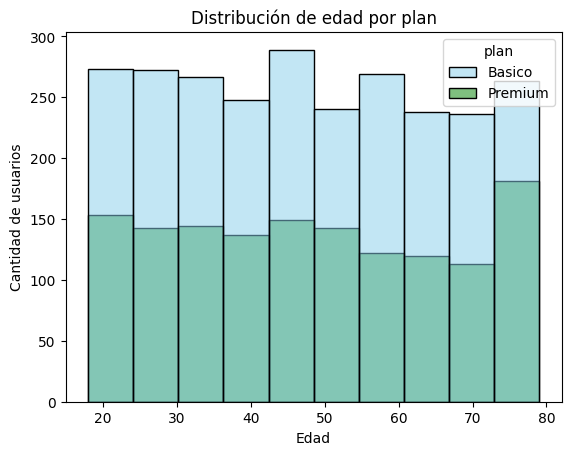

In [33]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La distribución de edades parece relativamente uniforme entre los 18 y 79 años, sin una concentración extrema en un rango específico.

- Los usuarios del plan `Basico` son más numerosos que los de `Premium` en casi todos los grupos de edad.

- No se observa una diferencia muy marcada entre planes según la edad, por lo que no parece existir un patrón fuerte de segmentación etaria entre `Basico` y `Premium`.

- La distribución no parece completamente simétrica, aunque tampoco presenta un sesgo extremo hacia la derecha o izquierda.

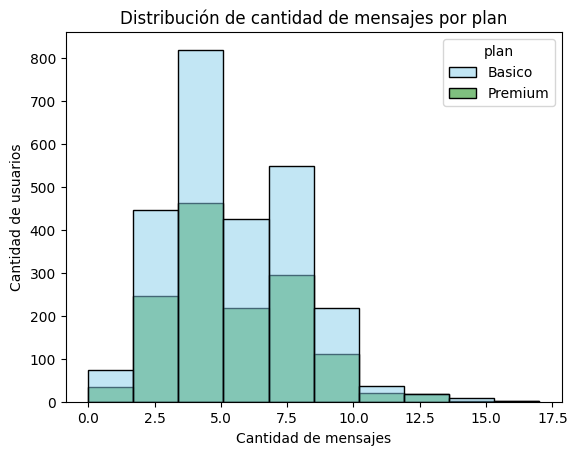

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 

- La mayor concentración de usuarios se encuentra entre 3 y 8 mensajes enviados.
- Los usuarios del plan Básico son más numerosos en casi todos los rangos, aunque esto también puede deberse a que hay más clientes en ese plan.
- La distribución presenta sesgo a la derecha, ya que pocos usuarios envían cantidades muy altas de mensajes.
-Existen algunos posibles outliers con más de 12 mensajes, aunque representan una proporción pequeña.

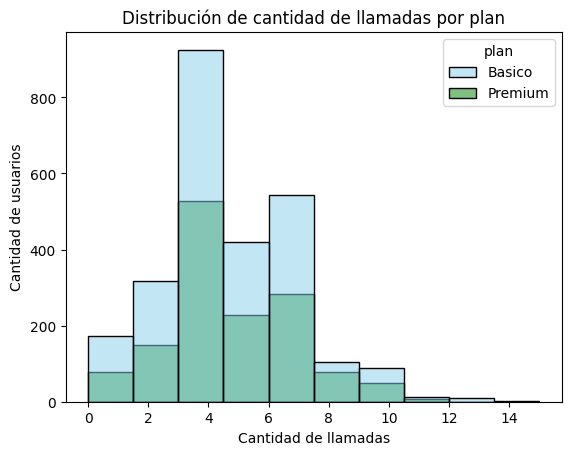

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La mayoría de los usuarios consumen entre 0 y 40 minutos de llamada.
- La distribución está claramente sesgada a la derecha, porque existen pocos usuarios con consumos extremadamente altos.
- Se observan posibles outliers cercanos a 120–150 minutos de llamada
- Los usuarios Premium parecen tener una presencia ligeramente mayor en rangos altos de consumo de minutos.

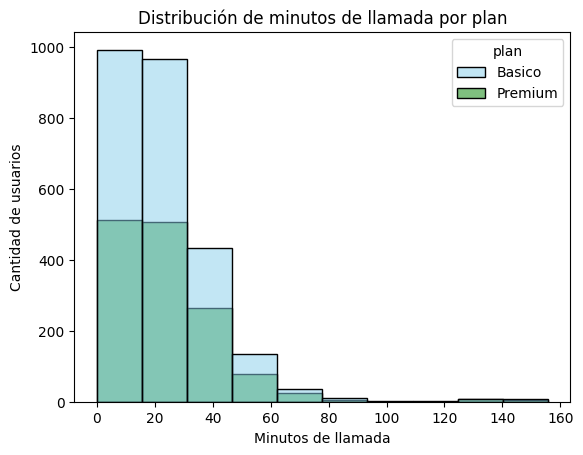

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La mayor parte de los usuarios realiza entre 3 y 7 llamadas.
- La distribución es asimétrica hacia la derecha, ya que pocos usuarios realizan muchas llamadas.
- Existen algunos posibles valores extremos con más de 10 llamadas.
- No se observan diferencias extremadamente marcadas entre los planes Básico y Premium en cantidad de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

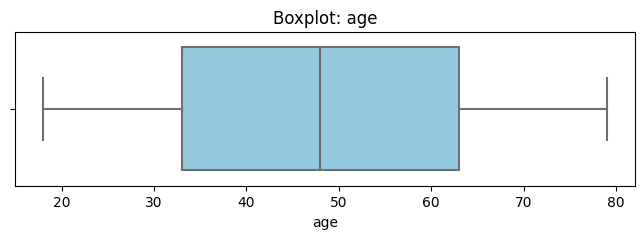

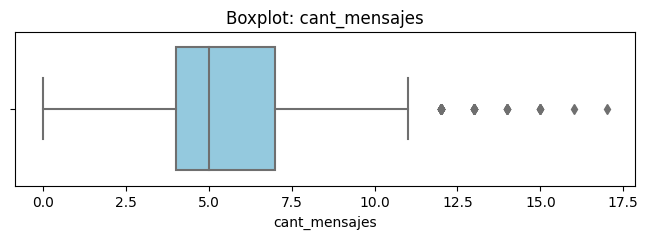

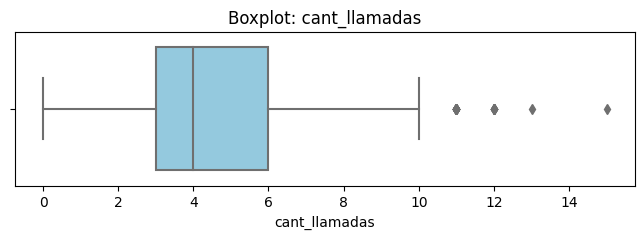

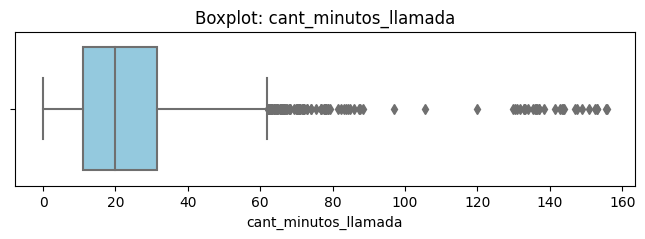

In [44]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No se observan outliers importantes en la edad. La distribución se encuentra dentro de rangos normales y relativamente simétrica.
- cant_mensajes: Sí existen outliers en valores altos de mensajes (aproximadamente desde 12 mensajes en adelante). Esto indica que algunos usuarios envían cantidades de mensajes muy superiores al comportamiento típico.
- cant_llamadas: Se observan algunos outliers altos en cantidad de llamadas, especialmente usuarios con más de 10 llamadas. La mayoría de usuarios se concentra entre 3 y 6 llamadas.
- cant_minutos_llamada: Es la variable con mayor presencia de outliers. Existen usuarios con consumos extremadamente altos de minutos (más de 60 minutos aproximadamente), lo que genera una distribución fuertemente sesgada a la derecha.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

In [46]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se recomienda mantener los outliers, ya que valores como 12–17 mensajes pueden representar usuarios muy activos y siguen siendo comportamientos posibles dentro del negocio.
- cant_llamadas: Se recomienda mantener los outliers, porque aunque existen usuarios con muchas llamadas (hasta 15), estos valores no parecen imposibles y pueden representar clientes con alto uso del servicio.
- cant_minutos_llamada: Se recomienda revisar cuidadosamente los outliers altos. Valores cercanos a 150 minutos son muy extremos respecto al comportamiento típico y podrían representar usuarios intensivos, errores de captura o casos atípicos; por ahora se pueden mantener para análisis exploratorio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [51]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [53]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [54]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

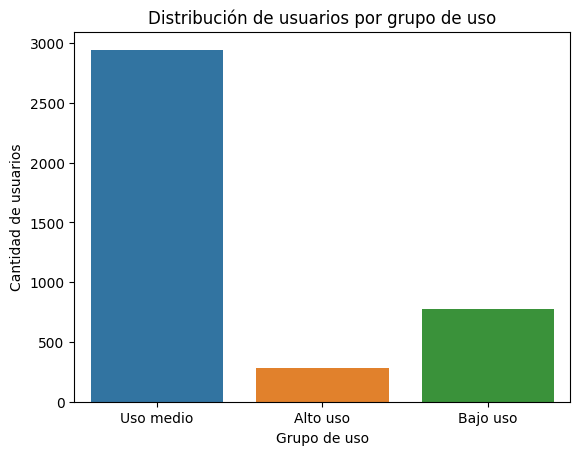

In [55]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

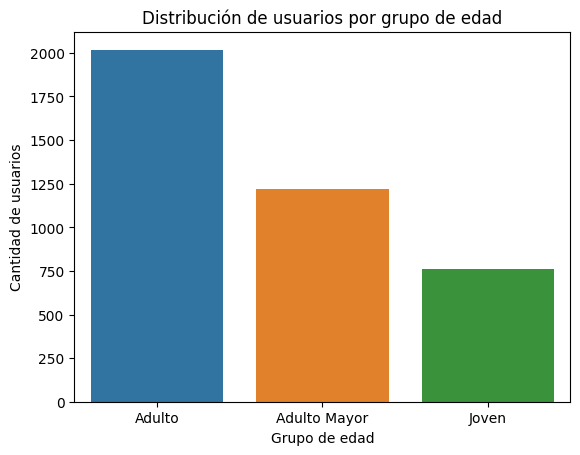

In [56]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna `city` presentó 469 valores nulos (11.7%) y 96 registros con el valor inválido `"?"`, los cuales fueron reemplazados por `NA`.
- La columna `age` contenía el valor sentinel `-999`, el cual fue reemplazado por la mediana para evitar sesgos en el análisis.
- En `reg_date` se detectaron 40 registros con fechas en 2026, consideradas fuera del rango esperado del proyecto.
- Las columnas `duration` y `length` presentaron altos porcentajes de nulos, pero se confirmó que dependen del tipo de actividad (`call` o `text`), por lo que se mantuvieron como MAR.

🔍 **Segmentos por Edad**
- La mayor concentración de clientes pertenece al grupo `Adulto`, seguido por `Adulto Mayor`.
- El grupo `Joven` representa una menor proporción de usuarios dentro de la base analizada.
- Las edades muestran una distribución relativamente estable y sin outliers importantes después de la limpieza.

📊 **Segmentos por Nivel de Uso**
- La mayoría de usuarios se concentra en el segmento `Uso medio`.
- Existe un grupo reducido de usuarios de `Alto uso`, especialmente en minutos de llamadas y mensajes.
- Se identificaron outliers en `cant_mensajes`, `cant_llamadas` y principalmente en `cant_minutos_llamada`.

➡️ Esto sugiere que ...

- ConnectaTel tiene una base de clientes principalmente adulta con patrones de uso moderados.
- Los usuarios intensivos podrían representar clientes de alto valor para estrategias premium o corporativas.
- Los outliers en minutos de llamadas podrían indicar oportunidades comerciales o posibles anomalías que deben monitorearse.
  
💡 **Recomendaciones**
- Diseñar planes diferenciados para usuarios de alto consumo de llamadas y mensajes.
- Implementar monitoreo de valores extremos para detectar fraudes, errores o clientes corporativos.
- Mejorar la calidad del registro de ciudades y fechas para reducir inconsistencias futuras.

- Crear campañas segmentadas según edad y nivel de uso para aumentar retención y satisfacción.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`